In [4]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(123)

In [5]:
def exact_solution(x):
    return torch.sin(torch.pi*x)

class FCN(nn.Module):
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, t):
        t = self.fcs(t)
        t = self.fch(t)
        t = self.fce(t)
        return t

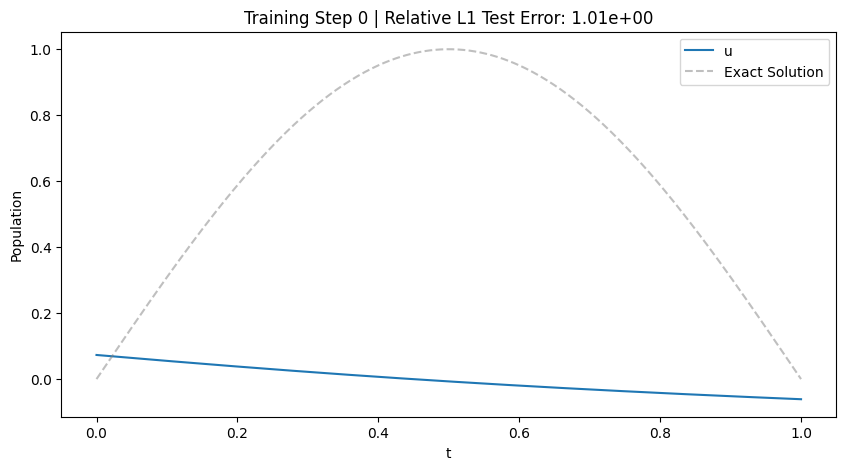

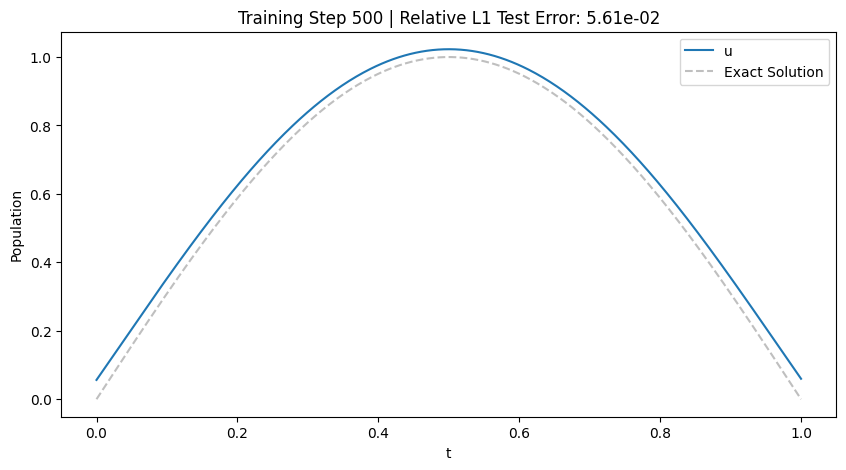

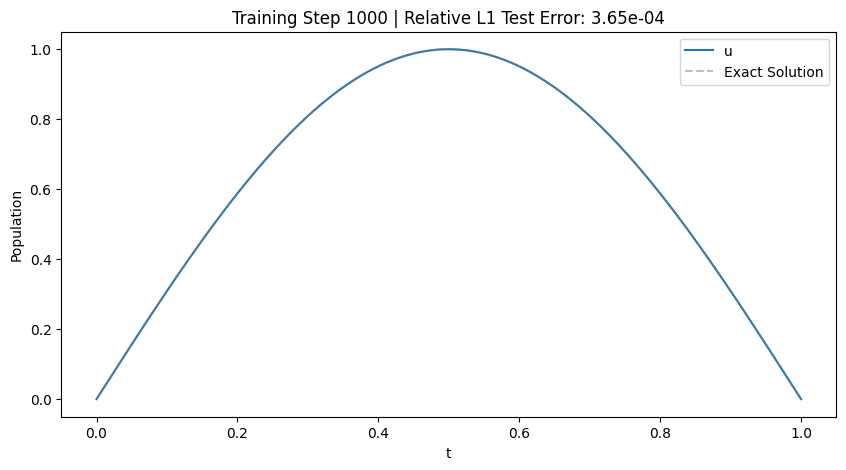

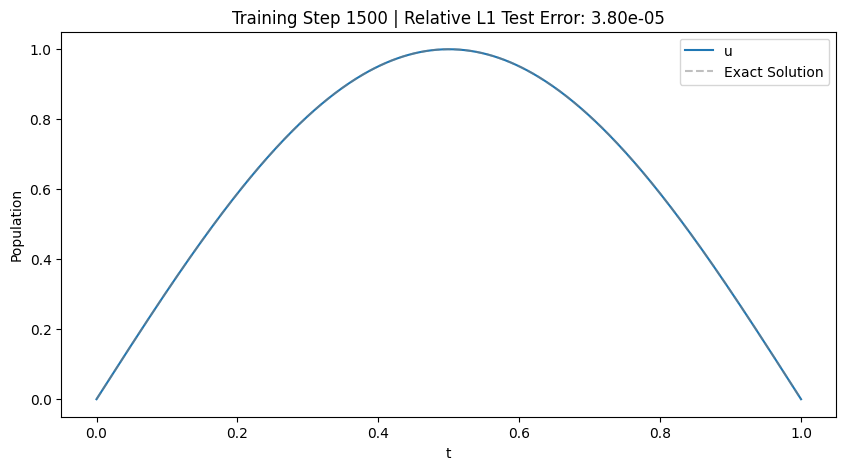

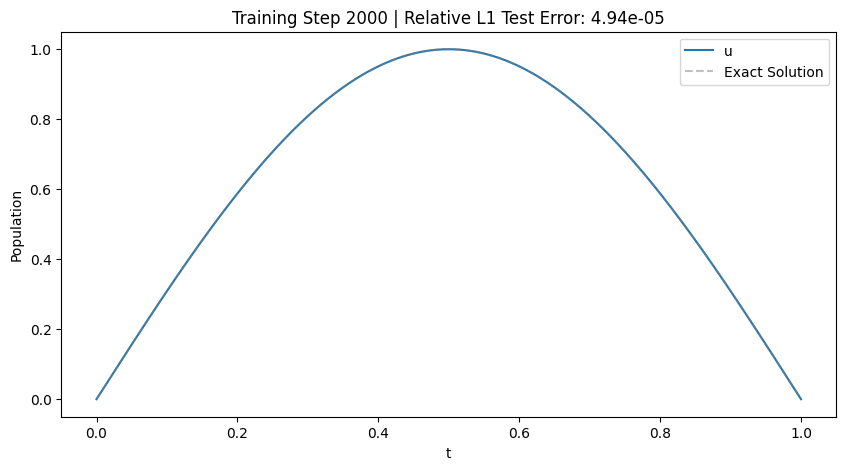

Total training time: 14.40 seconds


In [6]:
# 1. Setup Network and Data
# Input: t, Output: [u]
pinn = FCN(1, 1, 32, 3)

# Initial condition point (t=0)
t_boundary1 = torch.tensor([[0.0]], requires_grad=True)
t_boundary2 = torch.tensor([[1.0]], requires_grad=True)

# Collocation points for physics loss (t in [0, 1])
t_physics = torch.linspace(0, 1, 500).view(-1, 1).requires_grad_(True)

optimiser = torch.optim.Adam(pinn.parameters(), lr=1e-3)

# 2. Training Loop
start_time = time.time()
for i in range(2001):
    optimiser.zero_grad()

    # --- Initial Condition (Boundary) Loss ---
    u_0 = pinn(t_boundary1)
    u_1 = pinn(t_boundary2)
    dudx_0 = torch.autograd.grad(u_0, t_boundary1, torch.ones_like(u_0), create_graph=True)[0]
    dudx_1 = torch.autograd.grad(u_1, t_boundary2, torch.ones_like(u_1), create_graph=True)[0]


    loss_u0 = torch.mean((u_0 - 0.0)**2)
    loss_u1 = torch.mean((u_1 - 0.0)**2)
    loss_dudx0 = torch.mean((dudx_0 - torch.pi)**2)
    loss_dudx1 = torch.mean((dudx_1 + torch.pi)**2)

    # --- Physics Loss (System of ODEs) ---
    u = pinn(t_physics)

    # Gradients
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]

    # Residuals
    res = -d2udt2 + np.pi * np.pi * u - 2*(np.pi**2) * torch.sin(torch.pi*t_physics)

    loss_physics = torch.mean(res**2)

    # --- Total Loss ---
    loss = loss_u0 + loss_u1 + loss_dudx0 + loss_dudx1 + loss_physics

    loss.backward()
    optimiser.step()

    u_exact = exact_solution(t_physics).detach()

    # 3. Visualization
    if i % 500 == 0:
        with torch.no_grad():
            t_test = torch.linspace(0, 1, 500).view(-1, 1)
            pred_test = pinn(t_test)
            relative_l1_error = torch.sum(torch.abs(pred_test - u_exact)) / torch.sum(torch.abs(u_exact))

        plt.figure(figsize=(10, 5))
        plt.plot(t_test.numpy(), pred_test.numpy(), label="u", color="tab:blue")
        plt.plot(t_test.numpy(), u_exact, label="Exact Solution", color="grey", alpha=0.5, linestyle="--")
        plt.title(f"Training Step {i} | Relative L1 Test Error: {relative_l1_error.item():.2e}")
        plt.xlabel("t")
        plt.ylabel("Population")
        plt.legend()
        plt.show()

print(f"Total training time: {time.time() - start_time:.2f} seconds")

In [7]:
# 1. Define collocation points
t_obs = torch.linspace(0, 1, 30).view(-1, 1)

# 2. Generate true data from exact solution
u_true = exact_solution(t_obs)

# 3. Add 2% Gaussian noise to simulate experimental error for obs data
noise_level = 0.02
u_obs = u_true + noise_level * torch.randn_like(u_true)

# Detach to ensure these are constants for the inverse problem
u_obs = u_obs.detach()

In [8]:
# 1. Setup Network (Input: t, Output: [u])
pinn_inv = FCN(1, 1, 32, 3)
pinn_inv.load_state_dict(pinn.state_dict())   # ← ADD THIS

# 2. Define unknown parameters as trainable variables
# Initial guesses: starting at 1.0 for both
alpha = nn.Parameter(torch.tensor([8.0], requires_grad=True))

# 3. Define collocation points
t_physics = torch.linspace(0, 1, 100).view(-1, 1).requires_grad_(True)

# 4. Optimizer includes the parameters alpha and beta
optimizer = torch.optim.Adam(list(pinn_inv.parameters()) + [alpha], lr=1e-3)

Iteration 0 | Loss: 1.73e+00 | alpha: 8.0010
Iteration 2000 | Loss: 2.86e-02 | alpha: 8.7805
Iteration 4000 | Loss: 1.24e-02 | alpha: 9.3326
Iteration 6000 | Loss: 1.17e-03 | alpha: 9.6175
Iteration 8000 | Loss: 6.21e-04 | alpha: 9.7610
Iteration 10000 | Loss: 4.24e-04 | alpha: 9.8306
Iteration 12000 | Loss: 3.87e-04 | alpha: 9.8648

Final discovered alpha: 9.8648 (True: 9.8596)
Total training time: 68.82 seconds


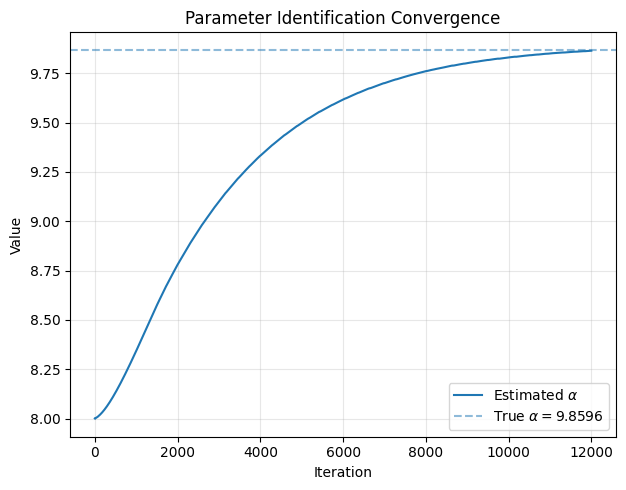

In [9]:
# Lists to store the history of alpha and beta for plotting
alpha_history = []
beta_history = []
loss_history = []

start_time = time.time()
iterations = 12001

for i in range(iterations):
    optimizer.zero_grad()

    # --- Data Loss ---
    # Compare predictions at the noisy observation points
    pred_obs = pinn_inv(t_obs)
    loss_data = torch.mean((pred_obs - u_obs)**2)

    # --- Initial Condition (Boundary) Loss ---
    u_0 = pinn_inv(t_boundary1)
    u_1 = pinn_inv(t_boundary2)
    dudx_0 = torch.autograd.grad(u_0, t_boundary1, torch.ones_like(u_0), create_graph=True)[0]
    dudx_1 = torch.autograd.grad(u_1, t_boundary2, torch.ones_like(u_1), create_graph=True)[0]

    loss_u0 = torch.mean((u_0 - 0.0)**2)
    loss_u1 = torch.mean((u_1 - 0.0)**2)
    loss_dudx0 = torch.mean((dudx_0 - torch.pi)**2)
    loss_dudx1 = torch.mean((dudx_1 + torch.pi)**2)

    # --- Physics Loss (System of ODEs) ---
    u = pinn_inv(t_physics)

    # Gradients
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]

    # Residuals
    res = -d2udt2 + alpha * u - 2*alpha * torch.sin(torch.pi*t_physics)

    loss_physics = torch.mean(res**2)

    # --- Total Loss ---
    loss = loss_data + loss_physics + loss_u0 + loss_u1 + loss_dudx0 + loss_dudx1
    loss.backward()
    optimizer.step()

    # Record history for plotting
    alpha_history.append(alpha.item())
    loss_history.append(loss.item())

    if i % 2000 == 0:
        print(f"Iteration {i} | Loss: {loss.item():.2e} | alpha: {alpha.item():.4f}")

print(f"\nFinal discovered alpha: {alpha.item():.4f} (True: 9.8596)")
print(f"Total training time: {time.time() - start_time:.2f} seconds")

# --- Plotting the Parameter Convergence ---
plt.figure(figsize=(12, 5))

# Plot Alpha and Beta convergence
plt.subplot(1, 2, 1)
plt.plot(alpha_history, label=r'Estimated $\alpha$', color='tab:blue')
plt.axhline(y=torch.pi**2, color='tab:blue', linestyle='--', alpha=0.5, label=r'True $\alpha=9.8596$')
plt.title("Parameter Identification Convergence")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()